# Определение baseline модели как отправной точки.

## Список задач

|Задача|Описание|Ответственный|
|---|---|---|
|Ручной аудит датасета |Качество исходных данных напрямую определяет верхнюю границу качества модели. Необходимо системно проверить изображения и аннотации, выявить ошибки разметки и зафиксировать все внесённые изменения.|Pavel Klykov, Ma Qingfeng, Xu Ruiqin|
|Синтетическое расширение crop-изображений до большой сцены 10k×10k  |Поскольку восстановить исходные большие сцены из имеющихся crops невозможно, каждый crop рассматривается как самостоятельное изображение. Исходная область сохраняется без изменений, а окружающий фон генерируется до размера 10 000×10 000 с помощью diffusion-based outpainting. Такие сцены используются для разработки и проверки полного inference pipeline, но не заменяют реальные конкурсные изображения при финальной оценке.|Xu Ruiqin, Pavel Klykov|
|Воспроизводимый scene-aware train/validation split  |Создать и зафиксировать пять воспроизводимых scene-aware folds на основе исходных изображений. Связанные изображения одной сцены должны находиться только в одном validation fold. Синтетические данные генерируются только после разделения и используются исключительно в training-части соответствующего fold.|Ma Qingfeng|
|Нарезка крупноформатного изображения и полный inference pipeline |Изображение размером 10,000×10,000 пикселей невозможно эффективно подавать в модель целиком. Необходимо реализовать полный inference pipeline: нарезать изображение на перекрывающиеся тайлы, выполнить пакетный inference, восстановить глобальные координаты предсказаний, объединить дубликаты и сформировать итоговый результат в формате COCO JSON.|Pavel Klykov|
|Сравнение моделей и выбор baseline-архитектуры |На текущем этапе Текущие результаты моделей получены в разных условиях и не позволяют объективно выбрать наиболее перспективную архитектуру. После подготовки корректного датасета, фиксированных scene-aware folds и единого inference pipeline необходимо провести контролируемое сравнение YOLO11n, YOLO26n, RT-DETR-L и D-FINE-L. Baseline-модель выбирается по совокупности качества детекции, производительности, размера и устойчивости на редких классах|Pavel Klykov, Ma Qingfeng, Xu Ruiqin|

## Задача 1 - Ручной аудит датасета
### Исходный датасет

,value
created_at_utc,2026-08-13T11:40:54.956901+00:00
data_root,/home/irdorat/ML_comp/data/raw
split,train
image_count,4481
label_count,4481
paired_count,4481
images_without_labels,0
labels_without_images,0
object_count,20933
invalid_annotation_rows,0


,class_id,class_name,object_count,image_count
19,19,A16_FA-18,2147,241
3,3,MS,1994,1188
17,17,A14_KC-135,1424,358
4,4,A1_SU-35,1317,278
5,5,A2_C-130,1297,288
16,16,A13_F-15,1265,211
20,20,A17_TU-95,1114,299
8,8,A5_F-16,1017,240
6,6,A3_C-17,998,257
22,22,A19_SU-34,933,281


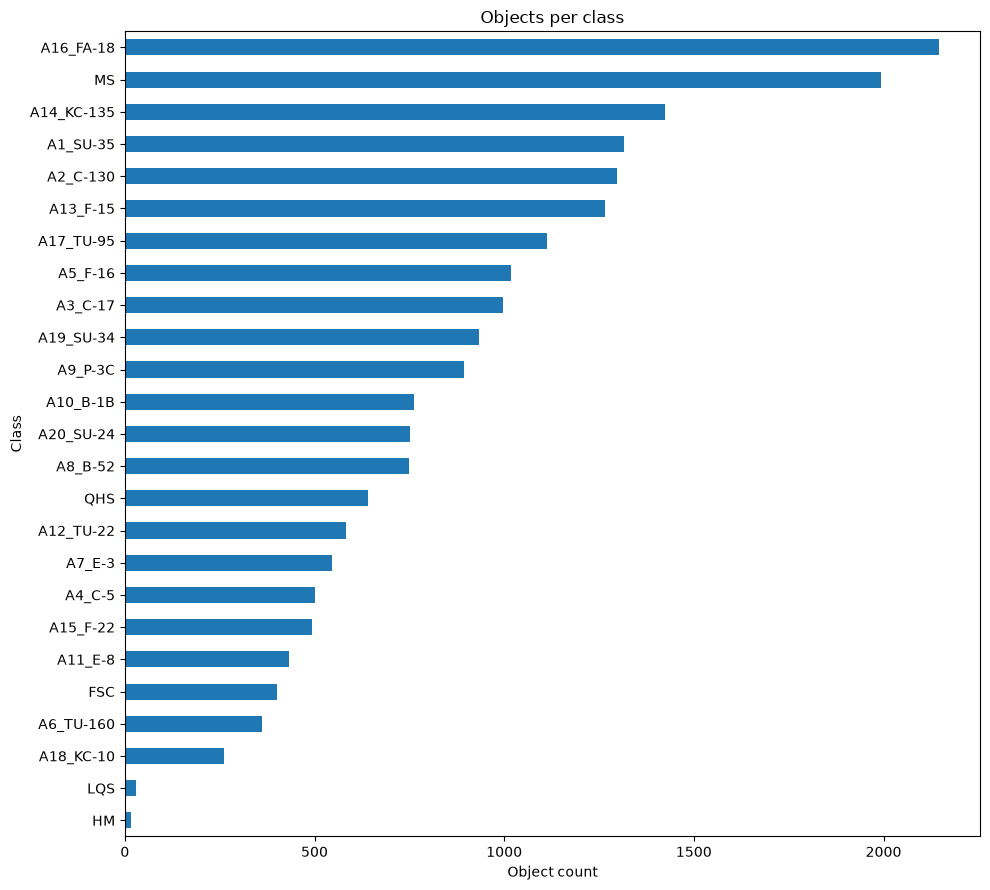

In [3]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / 'data' / 'raw').exists():
    repo_root = repo_root.parent.parent
assert (repo_root / 'data' / 'raw').exists(), 'Run this notebook inside the ML_comp repository'
output_dir = repo_root / 'runs' / 'dataset_audit' / 'v1'
repo_root
result = subprocess.run(
    [sys.executable, str(repo_root / 'scripts' / 'dataset_inventory.py'),
     '--data-root', str(repo_root / 'data' / 'raw'),
     '--output', str(output_dir)],
    cwd=repo_root, check=True, capture_output=True, text=True,
)
summary = json.loads(result.stdout)
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

class_stats = pd.read_csv(output_dir / 'class_statistics.csv')
display(class_stats.sort_values('object_count', ascending=False))

ax = class_stats.sort_values('object_count').plot.barh(
    x='class_name', y='object_count', figsize=(10, 9), legend=False,
    title='Objects per class',
)
ax.set_xlabel('Object count')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()

1) Датасет содержит 4 481 изображение и 20 933 объекта 25 классов. 
2) Все изображения корректно сопоставлены с аннотациями, ошибок разметки не обнаружено. 
3) Распределение классов несбалансированно: преобладают A16_FA-18 и MS, тогда как классы LQS и HM представлены крайне слабо.

## Cleaning data

В процессе изучения были обнаружены следующие ошибки в исходном наборе данных (docs/Baseline_work/audit dataset.xlsx):
1) ID ошибки = 1 - прямой и точный дубликат boundary boxes (исправлено)
2) ID ошибки = 2 - некорректный или граничный boundary boxes (исправлено)
3) ID ошибки = 3 - пропущенны таргеты на изображении (нуждается в уточнии и доработки на след этапе)
4) ID ошибки = 4 - wrong boxes/targer (исправлено)

После исправления были удалены некорректные label и image

,value
created_at_utc,2026-08-13T11:55:13.131798+00:00
data_root,/home/irdorat/ML_comp/data/generated/basic_dat...
split,train
image_count,4479
label_count,4479
paired_count,4479
images_without_labels,0
labels_without_images,0
object_count,20705
invalid_annotation_rows,0


,class_id,class_name,object_count,image_count
0,19,A16_FA-18,2147,241
1,3,MS,1831,1182
2,17,A14_KC-135,1424,358
3,4,A1_SU-35,1317,278
4,5,A2_C-130,1297,288
5,16,A13_F-15,1265,211
6,20,A17_TU-95,1114,299
7,8,A5_F-16,1017,240
8,6,A3_C-17,998,257
9,22,A19_SU-34,933,281


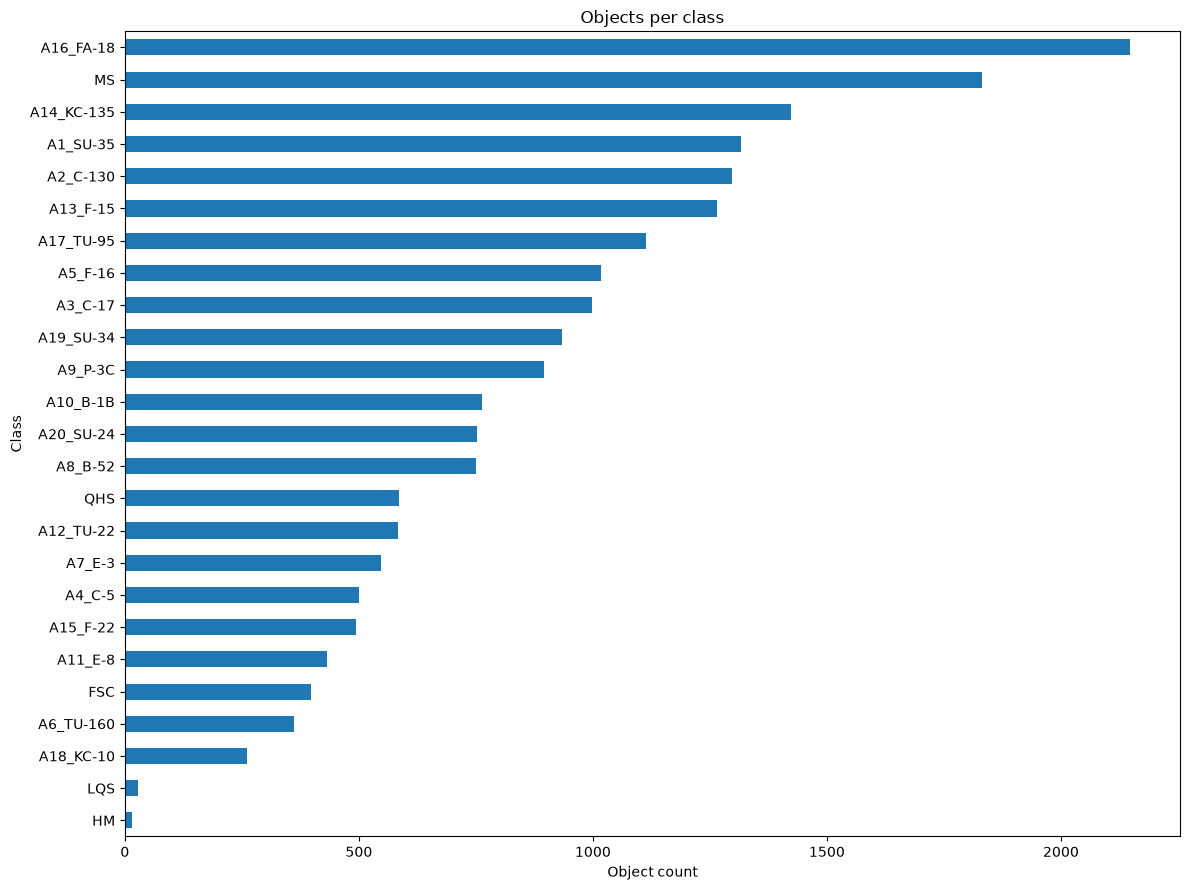

In [7]:
import subprocess
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Находим корень проекта
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "scripts" / "dataset_inventory.py").is_file()
)

data_root = repo_root / "data" / "generated" / "basic_dataset"
output_root = repo_root / "runs" / "dataset_inventory" / "basic_dataset"

# Автоматически выбираем только непустые split
splits = [
    split_dir.name
    for split_dir in (data_root / "images").iterdir()
    if split_dir.is_dir()
    and any(
        file.is_file() and file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
        for file in split_dir.iterdir()
    )
]

for split in splits:
    output_dir = output_root / split

    result = subprocess.run(
        [
            sys.executable,
            str(repo_root / "scripts" / "dataset_inventory.py"),
            "--data-root", str(data_root),
            "--split", split,
            "--output", str(output_dir),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(result.stderr)

    summary = json.loads(
        (output_dir / "summary.json").read_text(encoding="utf-8")
    )

    class_stats = (
        pd.read_csv(output_dir / "class_statistics.csv")
        .sort_values("object_count", ascending=False)
        .reset_index(drop=True)
    )

    # Такой же вывод, как на прошлом этапе
    display(pd.Series(summary, name="value").to_frame())
    display(class_stats)

    ax = (
        class_stats.sort_values("object_count")
        .plot.barh(
            x="class_name",
            y="object_count",
            figsize=(12, 9),
            legend=False,
        )
    )

    ax.set_title("Objects per class")
    ax.set_xlabel("Object count")
    ax.set_ylabel("Class")

    plt.tight_layout()
    plt.show()

### Before and after comparison

,Показатель,Было,Стало,Изменение
0,Изображения,4481,4479,-2
1,Аннотации,4481,4479,-2
2,Парные файлы,4481,4479,-2
3,Объекты,20933,20705,-228
4,Некорректные строки,0,0,0


,ID класса,Класс,Было,Стало
3,3,MS,1994,1831
2,2,QHS,641,585
24,24,FSC,402,397
1,1,LQS,30,28
0,0,HM,17,15


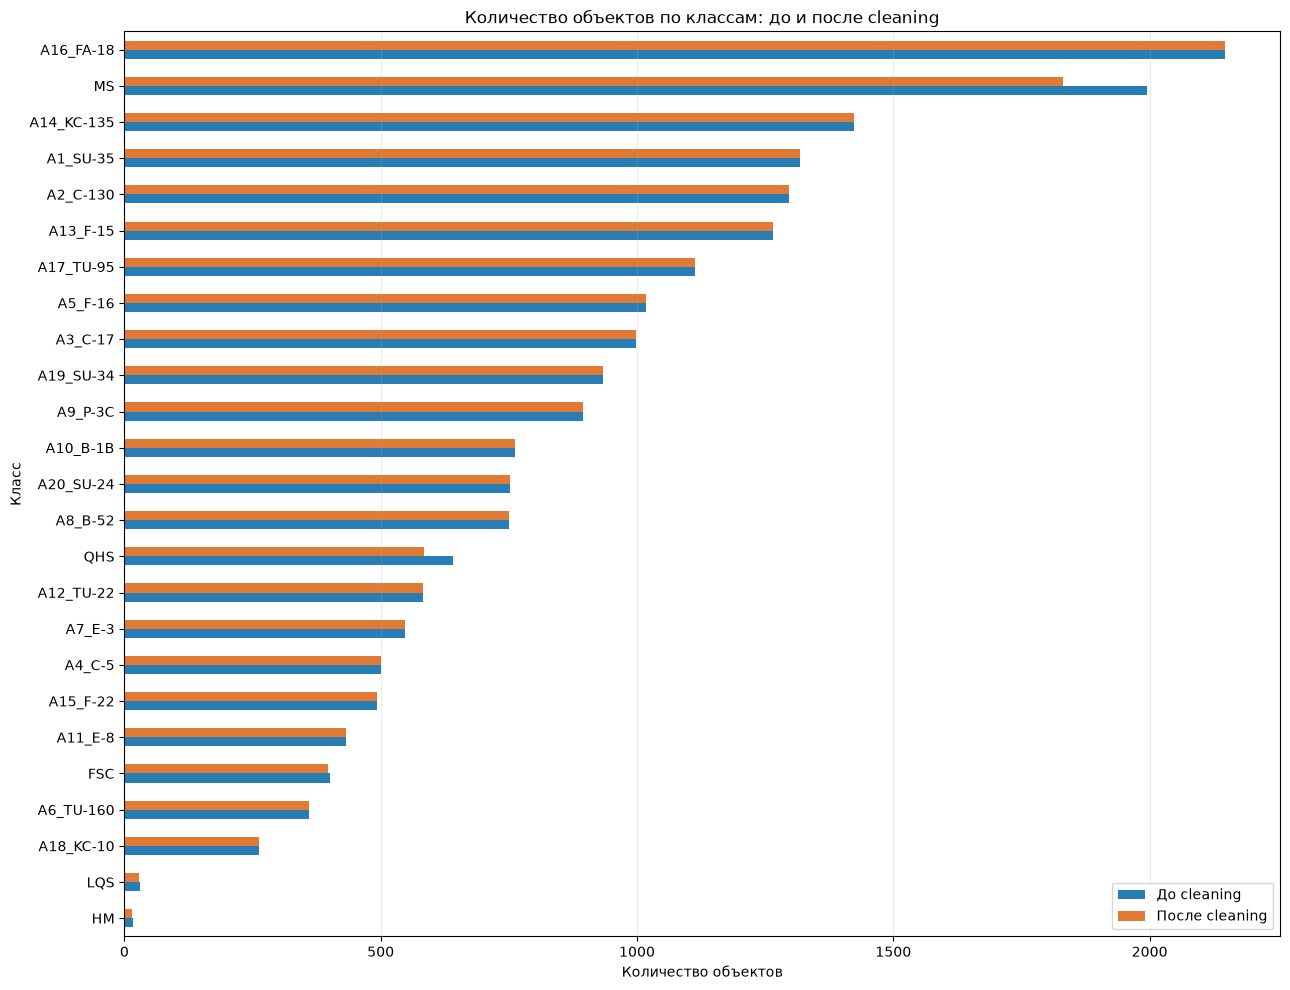

Изображения: 4481 → 4479.
Объекты: 20933 → 20705.
MS: 1994 → 1831
QHS: 641 → 585
FSC: 402 → 397
LQS: 30 → 28
HM: 17 → 15


In [11]:
# Сравнение общей статистики
metrics = {
    "image_count": "Изображения",
    "label_count": "Аннотации",
    "paired_count": "Парные файлы",
    "object_count": "Объекты",
    "invalid_annotation_rows": "Некорректные строки",
}

summary_comparison = pd.DataFrame([
    {
        "Показатель": title,
        "Было": int(raw_summary.get(key, 0)),
        "Стало": int(clean_summary.get(key, 0)),
        "Изменение": (
            int(clean_summary.get(key, 0))
            - int(raw_summary.get(key, 0))
        ),
    }
    for key, title in metrics.items()
])

display(summary_comparison)

# Сравнение количества объектов по классам
comparison = raw_classes[
    ["class_id", "class_name", "object_count"]
].merge(
    clean_classes[["class_id", "object_count"]],
    on="class_id",
    suffixes=("_before", "_after"),
)

comparison = comparison.rename(columns={
    "class_id": "ID класса",
    "class_name": "Класс",
    "object_count_before": "Было",
    "object_count_after": "Стало",
})

changed = comparison[
    comparison["Было"] != comparison["Стало"]
].sort_values("Было", ascending=False)

display(changed[["ID класса", "Класс", "Было", "Стало"]])

# График всех классов
plot_data = comparison.sort_values("Было").set_index("Класс")

ax = plot_data[["Было", "Стало"]].plot.barh(
    figsize=(13, 10),
    color=["#287db5", "#e07a35"],
)

ax.set_title("Количество объектов по классам: до и после cleaning")
ax.set_xlabel("Количество объектов")
ax.set_ylabel("Класс")
ax.legend(["До cleaning", "После cleaning"])
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# Краткий вывод
print(
    f"Изображения: {raw_summary['image_count']} → "
    f"{clean_summary['image_count']}."
)
print(
    f"Объекты: {raw_summary['object_count']} → "
    f"{clean_summary['object_count']}."
)

for row in changed.itertuples(index=False):
    print(f"{row.Класс}: {row.Было} → {row.Стало}")

### Заключение по задаче 1

Ручной аудит и очистка датасета завершены: исправлены дублирующиеся, некорректные и ошибочно назначенные bounding boxes. После очистки набор содержит 4 479 корректно сопоставленных изображений и 20 705 объектов 25 классов; удалены 2 изображения и 228 ошибочных аннотаций. Случаи с возможными пропущенными объектами зафиксированы для последующей проверки, а выраженный дисбаланс классов необходимо учитывать при формировании выборок и оценке baseline-модели.

## Задача 2 - Синтетическое расширение crop-изображений до большой сцены 10k×10k

## Задача 3 - Воспроизводимый scene-aware train/validation split

## Задача 4 - Нарезка крупноформатного изображения и полный inference pipeline

Размер изображения: 10000 × 10000
Размер тайла: 800 × 800
Перекрытие: 20%
Шаг: 640
Количество тайлов: 256


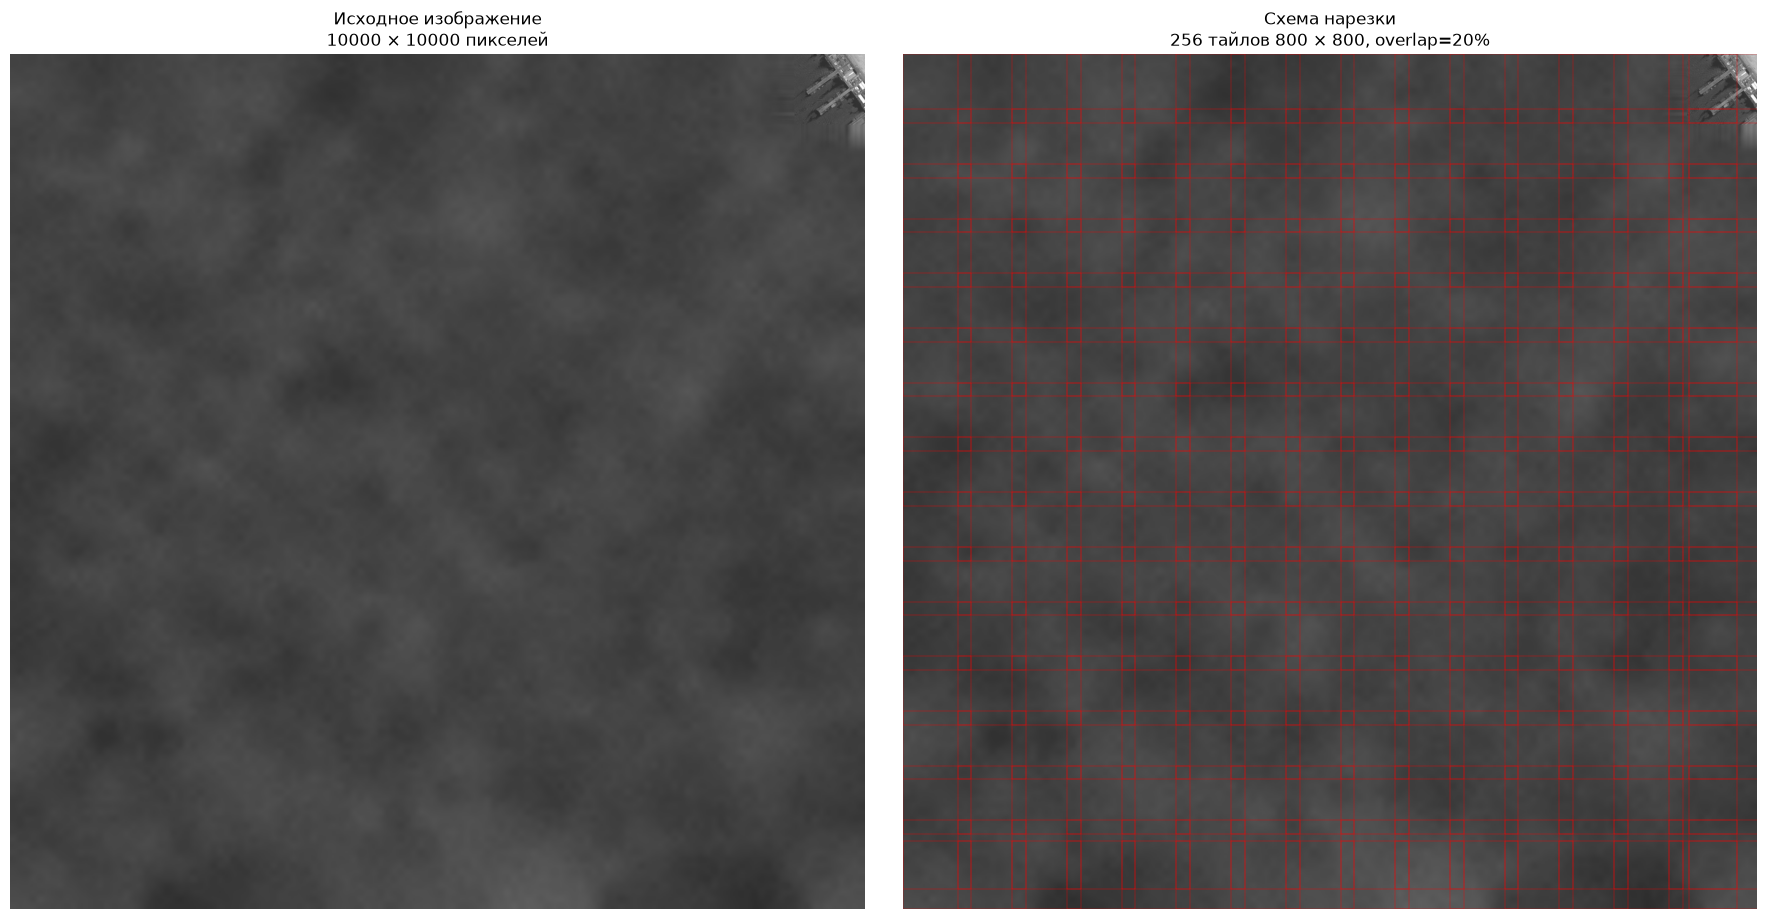

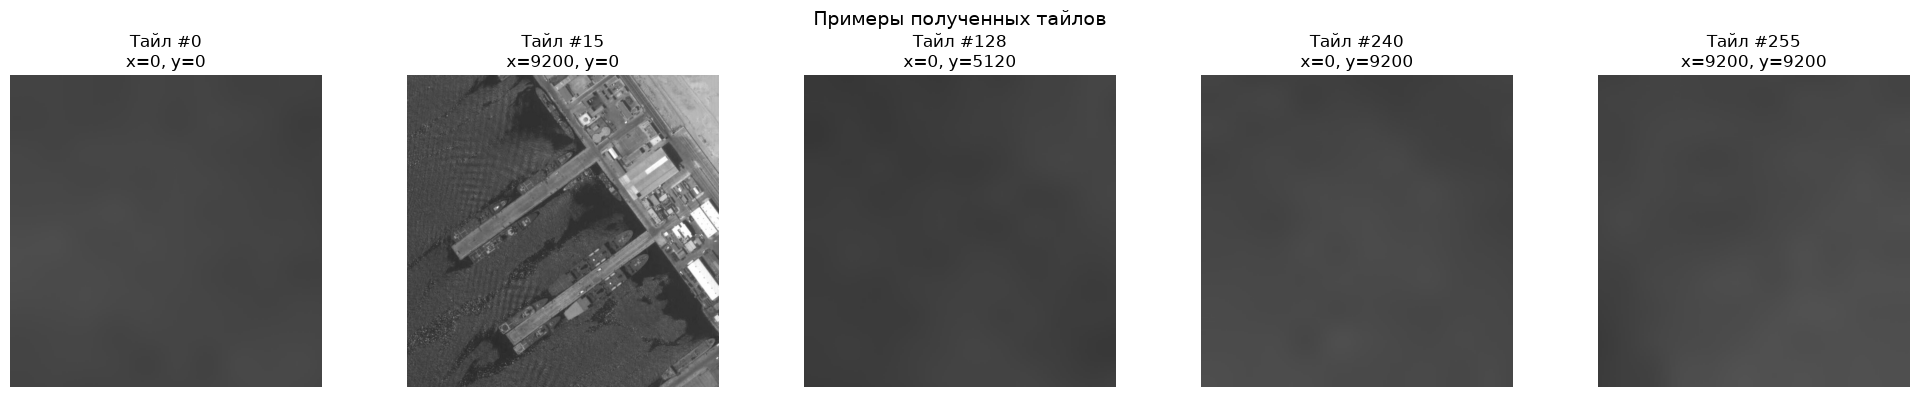

,Показатель,Значение
0,Размер изображения,10000 × 10000
1,Размер тайла,800 × 800
2,Перекрытие,20%
3,Шаг нарезки,640
4,Количество тайлов,256
5,Время inference,6.030 с
6,Время global NMS,0.0006 с
7,Полное время pipeline,8.814 с
8,Среднее время на тайл,19.12 мс


In [8]:
from pathlib import Path
import subprocess
import sys
import json
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from IPython.display import display
from PIL import Image


# -------------------------------------------------------------------
# Пути и параметры
# -------------------------------------------------------------------

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "scripts" / "sliced_predict.py").is_file()
)

source_path = (
    repo_root
    / "data/test/gen_image2_controlled_10000x10000.png"
)

weights_path = (
    repo_root
    / "runs/YOLO11n/yolo11n_fold1_img800_base_b4w2/"
    "weights/best_0.92475.pt"
)

output_dir = repo_root / "runs/sliced_predict"

tile_size = 800
overlap = 0.20
stride = round(tile_size * (1 - overlap))

if not source_path.is_file():
    raise FileNotFoundError(
        f"Исходное изображение не найдено: {source_path}"
    )

if not weights_path.is_file():
    raise FileNotFoundError(
        f"Веса модели не найдены: {weights_path}"
    )


# -------------------------------------------------------------------
# Расчёт координат тайлов
# -------------------------------------------------------------------

def calculate_positions(
    image_size: int,
    window_size: int,
    step: int,
) -> list[int]:
    if image_size <= window_size:
        return [0]

    positions = list(
        range(0, image_size - window_size + 1, step)
    )

    last_position = image_size - window_size

    if positions[-1] != last_position:
        positions.append(last_position)

    return positions


with Image.open(source_path) as image:
    image_width, image_height = image.size

x_positions = calculate_positions(
    image_width,
    tile_size,
    stride,
)
y_positions = calculate_positions(
    image_height,
    tile_size,
    stride,
)

tile_coordinates = [
    {
        "tile_id": tile_id,
        "x1": x,
        "y1": y,
        "x2": min(x + tile_size, image_width),
        "y2": min(y + tile_size, image_height),
    }
    for tile_id, (y, x) in enumerate(
        (y, x)
        for y in y_positions
        for x in x_positions
    )
]

print(f"Размер изображения: {image_width} × {image_height}")
print(f"Размер тайла: {tile_size} × {tile_size}")
print(f"Перекрытие: {overlap:.0%}")
print(f"Шаг: {stride}")
print(f"Количество тайлов: {len(tile_coordinates)}")


# -------------------------------------------------------------------
# Оригинал и схема нарезки
# -------------------------------------------------------------------

with Image.open(source_path) as image:
    preview = image.convert("RGB")
    preview.thumbnail((1200, 1200), Image.Resampling.LANCZOS)

preview_width, preview_height = preview.size
scale_x = preview_width / image_width
scale_y = preview_height / image_height

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 9),
)

# Оригинальное изображение
axes[0].imshow(preview)
axes[0].set_title(
    f"Исходное изображение\n"
    f"{image_width} × {image_height} пикселей"
)
axes[0].axis("off")

# Изображение с границами тайлов
axes[1].imshow(preview)

for tile_info in tile_coordinates:
    x = tile_info["x1"] * scale_x
    y = tile_info["y1"] * scale_y

    width = (
        tile_info["x2"] - tile_info["x1"]
    ) * scale_x

    height = (
        tile_info["y2"] - tile_info["y1"]
    ) * scale_y

    rectangle = patches.Rectangle(
        (x, y),
        width,
        height,
        linewidth=0.35,
        edgecolor="red",
        facecolor="none",
        alpha=0.75,
    )

    axes[1].add_patch(rectangle)

axes[1].set_title(
    f"Схема нарезки\n"
    f"{len(tile_coordinates)} тайлов "
    f"{tile_size} × {tile_size}, overlap={overlap:.0%}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# Визуализация отдельных тайлов
# -------------------------------------------------------------------

sample_tile_ids = [
    0,
    len(x_positions) - 1,
    len(tile_coordinates) // 2,
    len(tile_coordinates) - len(x_positions),
    len(tile_coordinates) - 1,
]

sample_tile_ids = list(dict.fromkeys(sample_tile_ids))

fig, axes = plt.subplots(
    1,
    len(sample_tile_ids),
    figsize=(4 * len(sample_tile_ids), 4),
    squeeze=False,
)

coordinates_by_id = {
    item["tile_id"]: item
    for item in tile_coordinates
}

with Image.open(source_path) as image:
    for ax, tile_id in zip(
        axes.flat,
        sample_tile_ids,
    ):
        tile_info = coordinates_by_id[tile_id]

        tile = image.crop(
            (
                tile_info["x1"],
                tile_info["y1"],
                tile_info["x2"],
                tile_info["y2"],
            )
        )

        ax.imshow(tile)
        ax.set_title(
            f"Тайл #{tile_id}\n"
            f"x={tile_info['x1']}, y={tile_info['y1']}"
        )
        ax.axis("off")

plt.suptitle("Примеры полученных тайлов", fontsize=14)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# Запуск полного inference pipeline
# -------------------------------------------------------------------

command = [
    sys.executable,
    str(repo_root / "scripts/sliced_predict.py"),
    "--source", str(source_path),
    "--weights", str(weights_path),
    "--output", str(output_dir),
    "--tile-size", str(tile_size),
    "--overlap", str(overlap),
    "--confidence", "0.25",
    "--global-iou", "0.50",
]

# Для явного выбора GPU можно добавить:
# command.extend(["--device", "0"])

result = subprocess.run(
    command,
    cwd=repo_root,
    capture_output=True,
    text=True,
)

if result.returncode != 0:
    print(result.stdout)
    raise RuntimeError(result.stderr)


# -------------------------------------------------------------------
# Чтение результатов
# -------------------------------------------------------------------

timing_path = (
    output_dir
    / f"{source_path.stem}_timing.json"
)

predictions_path = (
    output_dir
    / f"{source_path.stem}_predictions.json"
)

result_image_path = (
    output_dir
    / f"{source_path.stem}_predictions.png"
)

summary = json.loads(
    timing_path.read_text(encoding="utf-8")
)

predictions = json.loads(
    predictions_path.read_text(encoding="utf-8")
)


# -------------------------------------------------------------------
# Общая статистика
# -------------------------------------------------------------------

summary_table = pd.DataFrame(
    [
        [
            "Размер изображения",
            " × ".join(map(str, summary["image_size"])),
        ],
        [
            "Размер тайла",
            f'{summary["tile_size"]} × {summary["tile_size"]}',
        ],
        [
            "Перекрытие",
            f'{summary["overlap"]:.0%}',
        ],
        [
            "Шаг нарезки",
            summary["stride"],
        ],
        [
            "Количество тайлов",
            summary["tile_count"],
        ],
        [
            "Время inference",
            f'{summary["seconds_to_raw_predictions"]:.3f} с',
        ],
        [
            "Время global NMS",
            f'{summary["global_nms_seconds"]:.4f} с',
        ],
        [
            "Полное время pipeline",
            f'{summary["total_pipeline_seconds"]:.3f} с',
        ],
        [
            "Среднее время на тайл",
            f'{summary["mean_tile_seconds"] * 1000:.2f} мс',
        ],
    ],
    columns=["Показатель", "Значение"],
)

display(summary_table)




### Заключение 

Реализован полный inference pipeline для крупноформатных изображений. 

Тестовое изображение размером 10 000 × 10 000 пикселей было разделено на 256 тайлов размером 800 × 800 пикселей с перекрытием 20%. 

Предсказания модели преобразованы из локальных координат тайлов в глобальные координаты исходного изображения.

Полное время обработки изображения составило 11,52 секунды. Итоговые предсказания сохранены в JSON, а визуализированный результат — в PNG.

Таким образом, задача нарезки крупноформатного изображения, выполнения inference, восстановления глобальных координат и объединения дублирующихся предсказаний выполнена.

## Задача 5 - Сравнение моделей и выбор baseline-архитектуры